# Multiple Linear Regression In-class Exercise

Before starting the lab, the following exercise will perform a simple multiple variable linear fitting on a civil engineering dataset.  In doing this exercise, you will learn to:

* Load data from a `csv` file using the `pandas` package
* Visualize relations between different variables with a scatter plot.
* Fit a multiple variable linear model using the `sklearn` package
* Evaluate the fit.

We begin by loading the packages we will need.

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from sklearn import linear_model
import pandas as pd

## Download Data

Concrete is one of the most basic construction materials.  In this exercise, you will download a simple dataset for predicting the strength of concrete from the attributes of concrete.  The data set comes from this very nice
[kaggle competition](https://www.kaggle.com/maajdl/yeh-concret-data).  Kaggle has many excellent dataset for your project.  
You can download the data with the following command.  After running this command, you should have the file `data.csv` in your local folder.

In [2]:
fn_src = 'https://raw.githubusercontent.com/sdrangan/introml/master/unit03_mult_lin_reg/Concrete_Data_Yeh.csv'
fn_dst = 'data.csv'

import os
from six.moves import urllib

if os.path.isfile(fn_dst):
    print('File %s is already downloaded' % fn_dst)
else:        
    urllib.request.urlretrieve(fn_src, fn_dst)
    print('File %s downloaded' % fn_dst)

File data.csv is already downloaded


The `pandas` package has excellent methods for loading `csv` files.  YThe following command loads the `csv` file into a dataframe `df`.

In [3]:
df = pd.read_csv('data.csv')

Ues the `df.head()` to print the first few rows of the dataframe.

In [4]:
# TODO

df.head()

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In this exercise, the target variable will be the concrete strength in Megapascals, `csMPa`.  We will use the other 8 attributes as predictors to predict the strength.  

Create a list called `xnames` of the 8 names of the predictors.  You can do this as follows:
* Get the list of names of the columns from `df.columns.tolist()`.  
* Remove the last items from the list using indexing.

Print the `xnames`.

In [5]:
# TODO
#   xnames = ...
xnames = df.columns.tolist()
print(xnames)

['cement', 'slag', 'flyash', 'water', 'superplasticizer', 'coarseaggregate', 'fineaggregate', 'age', 'csMPa']


Get the data matrix `X` and target vector `y` from the dataframe `df`.  

Recall that to get the items from a dataframe, you can use syntax such as

    s = np.array(df['slag'])  
        
which gets the data in the column `slag` and puts it into an array `s`.  You can also get multiple columns with syntax like

    X12 = np.array(df['cement', 'slag'])  


In [16]:
# TODO
#    X = ...
#    y = ...
X = np.array(df[xnames[:-1]].values)
y = np.array(df['csMPa'].values)

In [17]:
X

array([[ 540. ,    0. ,    0. , ..., 1040. ,  676. ,   28. ],
       [ 540. ,    0. ,    0. , ..., 1055. ,  676. ,   28. ],
       [ 332.5,  142.5,    0. , ...,  932. ,  594. ,  270. ],
       ...,
       [ 148.5,  139.4,  108.6, ...,  892.4,  780. ,   28. ],
       [ 159.1,  186.7,    0. , ...,  989.6,  788.9,   28. ],
       [ 260.9,  100.5,   78.3, ...,  864.5,  761.5,   28. ]],
      shape=(1030, 8))

In [18]:
y

array([79.99, 61.89, 40.27, ..., 23.7 , 32.77, 32.4 ], shape=(1030,))

Using the subplot command, create two plots, side-by-side with:
* `y` vs. the `cement` on the left (attribute 0)
* `y` vs. the `water` on the right (attribute 3)
Label the axes and use the `plt.tight_layout()` to adjust the plots nicely at the end.

Text(0, 0.5, 'csmPA')

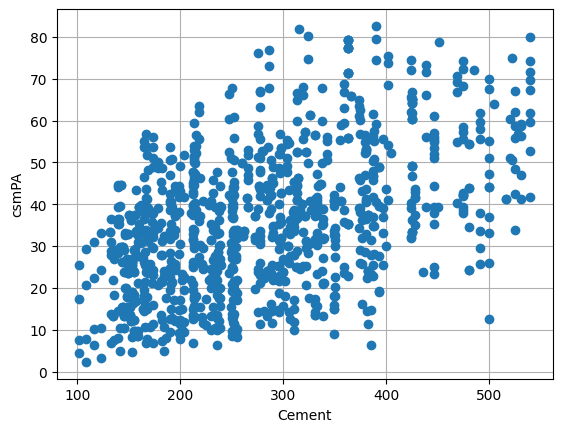

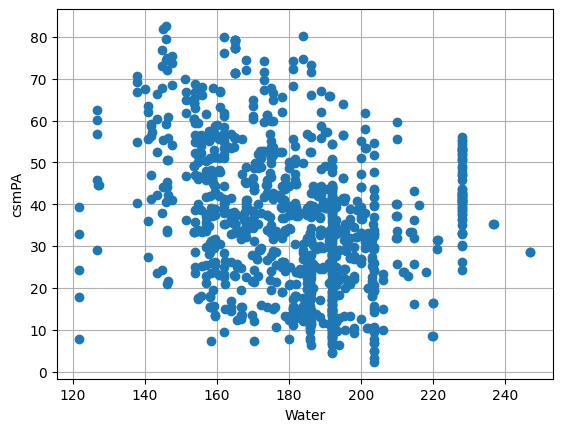

In [19]:
# TODO
plt.grid(True)
plt.plot(X[:,0],y,'o')
plt.xlabel("Cement")
plt.ylabel("csmPA")

plt.figure()
plt.grid(True)
plt.plot(X[:,3],y,'o')
plt.xlabel("Water")
plt.ylabel("csmPA")

## Split the Data into Training and Test

Split the data into training and test.  Use 30% for test and 70% for training.  You can do the splitting manually or use the `sklearn` package `train_test_split`.   Store the training data in `Xtr,ytr` and test data in `Xts,yts`.


In [20]:
from sklearn.model_selection import train_test_split

# TODO
Xtr,Xts,ytr,yts = train_test_split(X,y,test_size=0.3, random_state=2)

In [21]:
Xtr

array([[ 318. ,    0. ,  126. , ...,  861. ,  737. ,   28. ],
       [ 310. ,    0. ,    0. , ..., 1012. ,  830. ,    3. ],
       [ 255.5,  170.3,    0. , ..., 1026.6,  724.3,    7. ],
       ...,
       [ 290.4,    0. ,   96.2, ...,  961.2,  865. ,    3. ],
       [ 387. ,   20. ,   94. , ...,  938. ,  845. ,    7. ],
       [ 359. ,   19. ,  141. , ...,  942. ,  801. ,    7. ]],
      shape=(721, 8))

In [22]:
ytr

array([40.06, 11.85, 17.24,  9.01, 33.66, 71.3 , 40.6 , 49.99, 60.29,
       58.61, 66.6 , 55.9 , 17.44, 18.13, 10.22, 37.42, 14.5 , 18.13,
       11.41, 16.11, 33.4 , 40.27, 55.94, 19.42, 17.17, 43.01, 39.09,
       33.72, 21.48, 53.46, 47.1 ,  8.54, 67.57, 82.6 , 29.73, 10.54,
       26.05, 36.44, 40.15, 55.64, 25.18, 23.14, 40.93, 63.14, 39.  ,
       25.62, 24.29,  9.62, 13.2 , 51.04, 15.52,  7.4 , 17.2 , 44.86,
       18.2 , 39.4 , 26.23, 12.55, 37.68, 37.17, 38.46, 36.99, 14.64,
       34.68, 13.29, 17.57, 28.47, 27.23, 50.46, 29.75, 23.25, 10.09,
       23.52, 40.29, 39.84, 76.8 , 56.5 , 39.3 , 50.95, 32.84, 33.49,
       39.36, 23.08, 22.44, 56.81, 36.96, 11.48, 54.77, 32.76, 25.56,
       25.89, 24.05, 39.6 , 27.22, 38.6 , 19.99, 14.31, 39.7 , 19.11,
       24.85, 31.72, 32.04, 40.57, 30.22, 41.72, 66.78, 30.14, 33.8 ,
       72.99, 39.05, 33.21, 23.8 , 64.02, 36.59, 37.27, 13.46, 19.35,
       37.81, 41.05, 48.99,  9.99, 74.7 , 29.59, 36.8 , 27.92, 19.54,
       51.96, 31.87,

## Fit a Linear Model

Create a linear regression model object `reg` and fit the model on the training data.


In [23]:
# TODO
reg = linear_model.LinearRegression()
reg.fit(Xtr,ytr)

LinearRegression()

Compute the predicted values `yhat_tr` on the training data and print the `R^2` value on the training data.

In [27]:
# TODO
yhat_tr = reg.predict(Xtr)
normRSS_tr = np.mean((yhat_tr - ytr)**2)/(np.std(ytr)**2)
rsq_tr = 1 - normRSS_tr
print('R^2 training = ', rsq_tr)

R^2 training =  0.6228691034959632


In [29]:
from sklearn.metrics import r2_score
print(r2_score(ytr,yhat_tr))

0.6228691034959632


Now compute the predicted values `yhat_ts` on the test data and print the `R^2` value on the test data.

In [32]:
# TODO
yhat_ts = reg.predict(Xts)
normRSS_ts = np.mean((yhat_ts - yts)**2)/(np.std(yts)**2)
rsq_ts = 1 - normRSS_ts
print('R^2 testing = ', rsq_ts)

R^2 testing =  0.5918179969228498


In [33]:
print(r2_score(yts,yhat_ts))

0.5918179969228499


Create a scatter plot of the actual vs. predicted values of `y` on the test data.

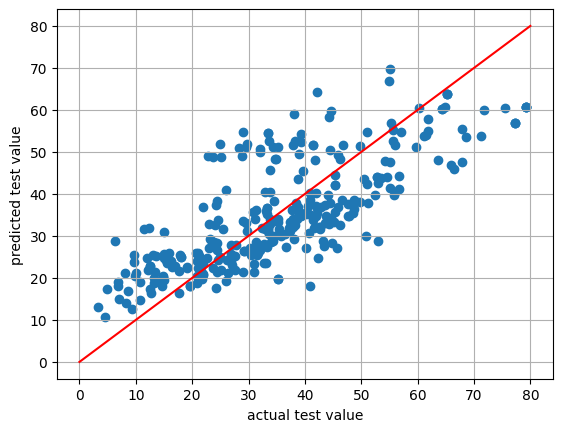

In [35]:
# TODO
plt.scatter(yts,yhat_ts)
plt.xlabel('actual test value')
plt.ylabel('predicted test value')
plt.plot([0,80],[0,80],'r')
plt.grid()


## Evaluating Different Variables

One way to see the importance of different variables is to compute the *normalized* coefficients:

    coeff_norm[j]  = reg.coef_[j] * std(Xtr[:,j]) / std(ytr) 
    
which represents the change in the target for a change of one standard deviation in the attribute `j`.  The change in the target is normalized by its standard deviation.  

Compute the `coeff_norm` for the 8 attributes and plot the values using a `plt.stem()` plot.

In [36]:
reg.coef_

array([ 0.12440852,  0.10265346,  0.09268255, -0.15552938,  0.24385875,
        0.01614699,  0.01874632,  0.10805656])

In [37]:
reg.intercept_

np.float64(-20.259632070267564)

In [38]:
# TODO
coeff_norm = reg.coef_ * np.std(Xtr, axis=0)/np.std(ytr)

In [39]:
coeff_norm

array([ 0.79008748,  0.52989576,  0.34772141, -0.20076383,  0.08821865,
        0.07434139,  0.09058852,  0.41718901])

<StemContainer object of 3 artists>

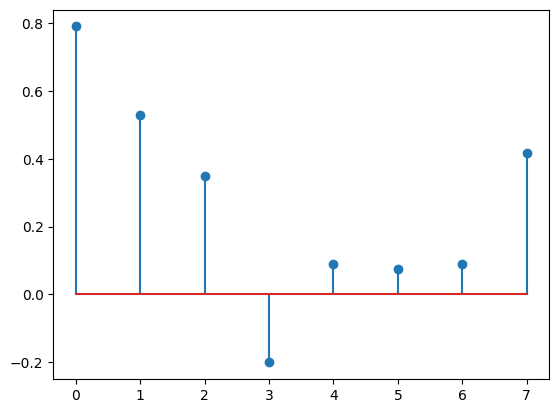

In [40]:
plt.stem(coeff_norm)

Which variable has the highest normalized coefficient, and hence most influence on the concrete strength?

In [42]:
# TODO
imax = np.argmax(np.abs(coeff_norm))
xnames[imax]

'cement'